# Out-of-sample test — $\gamma$ sweep

Train long-only mean-variance portfolios on the **first 3 months**, then see which $\gamma$ makes the most profit in the **held-out last month**. Same softmax optimizer as `portfolio_short_window`, swept over several $\gamma$, benchmarked against a 1/N equal-weight portfolio. This is the honest test — in-sample Sharpe is not allowed to count.


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from stonks import get_prices, to_returns

%matplotlib inline


## Parameters

Total window = train + test months. We slice the last `(TRAIN+TEST)` months from the cached 2-year prices.


In [30]:
TOP_N = 500
TRAIN_MONTHS = 3
TEST_MONTHS = 1
PERIOD = "2y"      # cached; we slice the last TRAIN+TEST months
GAMMAS = [1, 2, 5, 10, 20, 50, 200]
LAMBDA = 0.0       # concentration reward lambda*sum(w^2); 0 = off (dense)
torch.manual_seed(0)

## Fetch the 4-month window and split train / test

`dropna` on the whole window keeps only stocks with data across **both** periods, so train and test use the same universe.


In [31]:
prices = get_prices(top_n=TOP_N, period=PERIOD, interval="1d", field="close")
last = pd.Timestamp(prices.columns[-1])
start = last - pd.DateOffset(months=TRAIN_MONTHS + TEST_MONTHS)
returns = to_returns(prices.loc[:, prices.columns >= start]).dropna()

test_start = last - pd.DateOffset(months=TEST_MONTHS)
train = returns.loc[:, returns.columns < test_start]
test  = returns.loc[:, returns.columns >= test_start]
N = returns.shape[0]
print(f"universe N={N}  |  train {train.shape}  |  test {test.shape}")


universe N=453  |  train (453, 61)  |  test (453, 24)


## Train: $\mu$, $\Sigma$ on the training window


In [32]:
tr_np = train.to_numpy(dtype=float)
U, S, Vt = np.linalg.svd(tr_np)
K = 4
tr_np = (U[:,:K]*S[:K]) @ Vt[:K]
te_np = test.to_numpy(dtype=float)
mu_tr = tr_np.mean(axis=1)
Xc = tr_np - mu_tr[:, None]

# idiosyncratic variance Psi = variance not explained by the K factors:
# diag(full sample cov) - diag(low-rank cov), clamped to >= 0
_Raw = train.to_numpy(float)
_Rc = _Raw - _Raw.mean(axis=1, keepdims=True)
Psi = np.clip((_Rc**2).sum(1) / (tr_np.shape[1] - 1) - (Xc**2).sum(1) / (tr_np.shape[1] - 1), 0, None)

Sigma_tr = (Xc @ Xc.T) / (tr_np.shape[1] - 1)
Sigma_tr = Sigma_tr + np.diag(Psi)     # full rank again

mu_t = torch.tensor(mu_tr, dtype=torch.float64)
Sig_t = torch.tensor(Sigma_tr, dtype=torch.float64)


## Optimize a long-only portfolio for each $\gamma$ (train only)

Maximize $\mu_{\text{tr}}^\top w - \tfrac{\gamma}{2}\, w^\top \Sigma_{\text{tr}} w$ with $w = \mathrm{softmax}(z)$ ($w\ge0$, $\sum w=1$). Weights are chosen using **only** the training window.


In [33]:
def optimize(gamma, lam=0.0):
    z = torch.randn(N, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([z], lr=0.5)
    for _ in range(8000):
        opt.zero_grad()
        w = torch.softmax(z, dim=0)
        # +lam*sum(w^2): concentration reward (Herfindahl) for sparsity.
        # (||w||_1 is constant on the long-only simplex, so L1 can't sparsify here.)
        loss = -(mu_t @ w - 0.5 * gamma * w @ Sig_t @ w + lam * (w * w).sum())
        loss.backward()
        opt.step()
    return torch.softmax(z, dim=0).detach().numpy()

weights = {g: optimize(g, LAMBDA) for g in GAMMAS}
weights["1/N"] = np.ones(N) / N
print("optimized", len(GAMMAS), "gamma values + 1/N benchmark")

optimized 7 gamma values + 1/N benchmark


## Validate: realized profit in the held-out last month

For each set of (frozen) weights, compute the daily portfolio return on the test window and the **compounded profit** over the month — the quantity we rank by.


In [34]:
def perf(w, R):
    rp = w @ R                         # daily portfolio returns
    profit = np.prod(1 + rp) - 1        # compounded over the window
    vol = rp.std() * np.sqrt(252)
    sharpe = rp.mean() / rp.std() * np.sqrt(252) if rp.std() > 0 else np.nan
    return profit, vol, sharpe

rows = []
for key, w in weights.items():
    profit, vol, sh = perf(w, te_np)
    _, _, sh_tr = perf(w, tr_np)
    rows.append({"strategy": key,
                 "holdings": int((np.abs(w) > 1e-3).sum()),
                 "test_profit%": profit * 100,
                 "test_vol%": vol * 100,
                 "test_Sharpe": sh,
                 "train_Sharpe": sh_tr})
results = pd.DataFrame(rows).sort_values("test_profit%", ascending=False).reset_index(drop=True)
results


,strategy,holdings,test_profit%,test_vol%,test_Sharpe,train_Sharpe
0,5,17,13.591630,62.667357,2.449408,4.232340
1,10,27,11.900929,33.702486,3.677470,4.431273
2,20,67,6.778081,19.556355,3.623065,4.603376
3,50,147,5.988315,10.451694,5.901895,4.700962
4,200,252,4.665621,7.373894,6.536214,4.673217
5,1/N,453,4.420647,14.124350,3.288957,1.776434
6,2,6,3.558154,100.080630,0.856036,3.922862
7,1,3,-9.399255,131.807290,-0.144707,3.669496


## Test-month equity curves


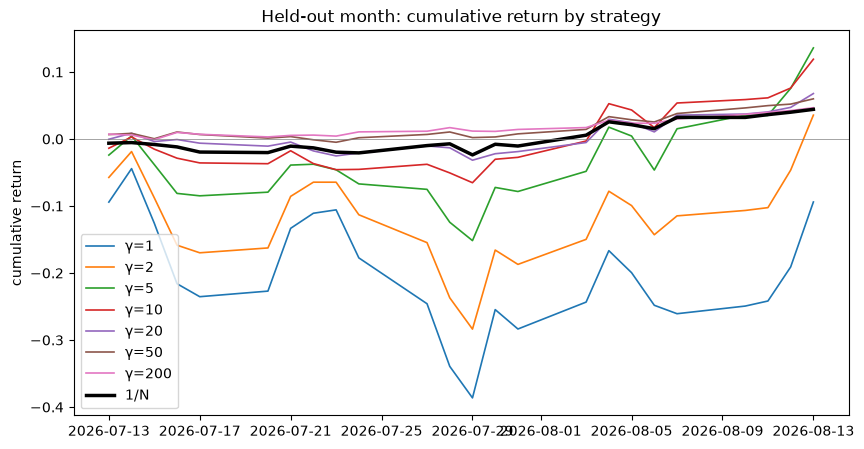

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
for key, w in weights.items():
    cum = np.cumprod(1 + w @ te_np) - 1
    ax.plot(test.columns, cum,
            color="black" if key == "1/N" else None,
            lw=2.5 if key == "1/N" else 1.2,
            label=f"{key}" if key == "1/N" else f"γ={key}")
ax.axhline(0, color="gray", lw=0.5)
ax.set_ylabel("cumulative return")
ax.set_title("Held-out month: cumulative return by strategy")
ax.legend()


## Sparsity via a concentration reward

The portfolios above are dense (dozens of holdings). To enforce **few holdings** we add a concentration reward $+\lambda\sum_i w_i^2$ (the Herfindahl index: $1/N$ for equal-weight, $1$ for a single stock). On the long-only simplex $\|w\|_1=\sum_i w_i=1$ is constant, so L1 can't sparsify here — $\sum_i w_i^2$ is the lever that actually varies with concentration. Sweep $\lambda$ at fixed $\gamma=20$:


In [ ]:
torch.manual_seed(0)
GAMMA_SWEEP = 20.0
LAMBDAS = [0, 0.001, 0.002, 0.005, 0.01, 0.02]
rows = []
for lam in LAMBDAS:
    w = optimize(GAMMA_SWEEP, lam)
    rp = w @ te_np
    rows.append({"lambda": lam, "holdings": int((w > 1e-3).sum()),
                 "test_profit%": (np.prod(1 + rp) - 1) * 100,
                 "test_vol%": rp.std() * np.sqrt(252) * 100,
                 "test_Sharpe": rp.mean() / rp.std() * np.sqrt(252)})
rp = (np.ones(N) / N) @ te_np
rows.append({"lambda": "1/N", "holdings": N,
             "test_profit%": (np.prod(1 + rp) - 1) * 100,
             "test_vol%": rp.std() * np.sqrt(252) * 100,
             "test_Sharpe": rp.mean() / rp.std() * np.sqrt(252)})
pd.DataFrame(rows)


### Reading it

$\lambda$ sparsifies as expected (holdings fall as $\lambda$ rises), but the held-out profit is **wildly non-monotonic in $\lambda$** — a value that wins this month can lose next month. That's the warning: sparse portfolios are high-variance bets, and tuning $\lambda$ on a single test month is itself overfitting. Pick $\lambda$ by walk-forward over many months, not by one month's profit.


### Takeaway

- **In-sample lies, out-of-sample tells.** Train Sharpe rises with $\gamma$ (looks better and better), but every optimized portfolio **lost money** in the held-out month — while 1/N equal-weight **made money**. This is the textbook result: with a noisy $\mu$, mean-variance fits noise and 1/N (no estimation error) wins out-of-sample.
- **Low $\gamma$ was worst** (concentrated on a few high-$\mu$ names that reversed); high $\gamma$ (diversified) lost the least among the optimized books but still didn't beat cash or 1/N.
- **Caveat:** it's a single test month — one regime. A real evaluation would walk-forward over many months. But the lesson is robust: the bottleneck is the **estimate of $\mu$** (and $\Sigma$), not the optimizer. Next step to actually beat 1/N: shrink $\mu$ toward a prior, or use a factor model / risk parity.
